<a href="https://colab.research.google.com/github/QuangDuy1512/ecommerce-behavior-analysis/blob/main/notebooks/07_Apriori_association_rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/drive/MyDrive/personal_projects/enriched_ecommerce_dataset.csv")
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,HourKey,...,Session_Action_Count,Product_Popularity,User_Activity,Purchase_Flag,Event_Score,Log_Price,AB_Group,AB_Group_Encoded,Hourly_Events,Is_Anomaly_Alert
0,2019-12-07 18:52:21,view,20100170,2232732110089618156,apparel.trousers,nika,88.81,575358172,d860e8d1-6364-4117-a85b-cf467df2e05f,2019-12-07 18,...,1,7,1,0,1,4.497696,Control,0,970,0
1,2019-12-29 10:30:43,view,12400194,2232732092087664982,electronics.audio.microphone,crown,84.94,542328720,e345748e-173f-4500-b300-64d230b07e6c,2019-12-29 10,...,1,4,1,0,1,4.453649,Treatment,1,1730,0
2,2019-12-18 18:43:25,view,4300183,2053013552385491165,appliances.sewing_machine,electrolux,90.07,514113327,35207372-6743-4834-8179-5488ca42b5aa,2019-12-18 18,...,1,54,1,0,1,4.511628,Control,0,1377,0
3,2019-12-02 10:15:35,view,4000175,2053013566142809077,construction.tools.generator,polaris,77.20,576024739,6ec31ca0-bcab-4a66-ab0d-8ddd96e1ae2b,2019-12-02 10,...,1,1,2,0,1,4.359270,Control,0,989,0
4,2019-12-16 23:31:13,view,31501161,2232732115617710964,apparel.shoes.keds,luminarc,107.85,588048847,0b624f68-eaa0-4a5e-a1df-5af55044e73c,2019-12-16 23,...,1,192,1,0,1,4.689971,Control,0,189,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674344,2019-12-15 15:28:48,view,12100567,2053013555397001616,appliances.kitchen.mixer,Unknown,45.24,575519990,44e1c585-1615-4782-9786-13b5e39b418e,2019-12-15 15,...,1,70,1,0,1,3.833845,Treatment,1,1361,0
674345,2019-12-19 09:28:21,view,100019496,2232732061804790604,furniture.bedroom.bed,ikea,210.30,588828669,eb54dd0a-35e1-42de-b581-b10d482a58ac,2019-12-19 09,...,1,2,8,0,1,5.353279,Control,0,1585,0
674346,2019-12-08 14:17:52,view,1004961,2232732093077520756,construction.tools.light,oppo,154.42,516349554,06ac90ed-e6e8-4851-838b-663631eddd94,2019-12-08 14,...,1,319,1,0,1,5.046131,Treatment,1,1134,0
674347,2019-12-31 15:01:29,view,100014343,2053013563835941749,appliances.kitchen.refrigerators,oneplus,1093.98,512455128,6ab74a83-5563-4e1a-91c6-da725ae18896,2019-12-31 15,...,1,110,4,0,1,6.998491,Treatment,1,743,0


# Khai phá luật kết hợp bằng Apriori

**Mục tiêu** là đi sâu vào hành vi mua sắm của nhóm khách hàng thực tế để tìm ra: "Những sản phẩm/thương hiệu nào thường được khách hàng bỏ vào giỏ hàng và mua cùng nhau?". Từ đó, bạn có thể thiết kế các gói sản phẩm (Product Bundling) hoặc đưa ra gợi ý (Recommendation System) chính xác.

Tập dữ liệu có tới 80,085 sản phẩm duy nhất. Mếu chạy Apriori trực tiếp trên mã sản phẩm, ma trận One-Hot sẽ có hơn 80,000 cột -> Tràn RAM/Crash.

=> Giải pháp tối ưu: Khai phá luật kết hợp ở cấp độ Thương hiệu (brand).

## Giai đoạn 1: Khai pháp luật ở cấp độ ngành hàng (Category level)

**Mục tiêu:** Tìm ra quy luật mua sắm vĩ mô (Ví dụ: Khách mua ngành hàng X thì 80% sẽ mua thêm ngành hàng Y).

### Bước 1: Chuẩn bị dữ liệu giao dịch (Transaction Preparation)

In [ ]:
df_clean = df[df['Is_Anomaly_Alert'] == 0].copy() # Loại bỏ Bot/Anomaly trước khi phân tích hành vi người dùng thật
df_purchases = df_clean[df_clean['Purchase_Flag'] == 1].copy()

# Tạo danh sách giỏ hàng theo Category
category_col = 'category_code'
transactions_cat = df_purchases.groupby('user_id')[category_col].apply(lambda x: list(set(x))).tolist()
transactions_cat = [t for t in transactions_cat if len(t) > 1]

print(f"[★] Chuẩn bị thành công: {len(transactions_cat)} giỏ hàng.")
print("Mẫu 3 giỏ hàng đầu tiên:", transactions_cat[:3])

[★] Chuẩn bị thành công: 190 giỏ hàng.
Mẫu 3 giỏ hàng đầu tiên: [['computers.desktop', 'electronics.audio.headphone'], ['apparel.shoes.moccasins', 'construction.tools.light'], ['apparel.shirt', 'construction.tools.light']]


### Bước 2: Biến đổi ma trận nhị phân (One-hot encoding)

*Mục tiêu: Chuyển đổi danh sách các giỏ hàng dạng chữ (Text) sang một ma trận nhị phân (0 và 1 hoặc True/False) bằng công cụ TransactionEncoder để máy tính có thể tính toán đại số.*

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

te_cat = TransactionEncoder()
te_ary_cat = te_cat.fit(transactions_cat).transform(transactions_cat)
df_hot_cat = pd.DataFrame(te_ary_cat, columns=te_cat.columns_)

### Bước 3: Xác định tập mục phổ biến (Frequent Itemsets)


In [ ]:
MIN_SUPPORT = 0.02
frequent_cats = apriori(df_hot_cat, min_support=MIN_SUPPORT, use_colnames=True)

# Sắp xếp theo chỉ số support giảm dần để xem những mục nào bán chạy nhất
frequent_cats = frequent_cats.sort_values(by='support', ascending=False).reset_index(drop=True)

print(f"[★] Hoàn thành: Tìm thấy {len(frequent_cats)} tập mục phổ biến đạt Support >= {MIN_SUPPORT}")
print("Top 10 tập mục phổ biến nhất:")
print(frequent_cats.head(10))

[★] Hoàn thành: Tìm thấy 33 tập mục phổ biến đạt Support >= 0.02
Top 10 tập mục phổ biến nhất:
    support                                     itemsets
0  0.557895                   (construction.tools.light)
1  0.178947                            (Unknown.Unknown)
2  0.110526                              (sport.bicycle)
3  0.089474                         (electronics.clocks)
4  0.084211                              (apparel.shoes)
5  0.084211           (appliances.kitchen.refrigerators)
6  0.073684               (appliances.personal.massager)
7  0.063158  (Unknown.Unknown, construction.tools.light)
8  0.057895              (computers.peripherals.printer)
9  0.057895             (construction.components.faucet)


### Bước 4: Sinh luật kết hợp (Association Rules)

*Từ các tập mục phổ biến đã lọc ở Bước 3, thuật toán sẽ tiến hành tính toán các xác suất điều kiện chuyên sâu để tìm ra Mối quan hệ nhân quả theo dạng: "Nếu khách hàng bỏ Ngành hàng A vào giỏ $\rightarrow$ Xác suất cao họ sẽ chốt đơn thêm Ngành hàng B".*

**Support** thể hiện mức độ phổ biến của một luật trong toàn bộ dữ liệu.

**Confidence** cho biết xác suất xuất hiện của B khi A đã xuất hiện.

**Lift** đo lường mức độ liên kết giữa A và B.
- Lift > 1: A và B có tương quan dương (thường xuất hiện cùng nhau).
- Lift = 1: A và B độc lập.
- Lift < 1: A và B có tương quan âm.

In [ ]:
# Sinh luật dựa trên chỉ số tương quan Lift
cat_rules = association_rules(frequent_cats, metric="lift", min_threshold=1.0)

# Sắp xếp các luật theo độ mạnh giảm dần (Lift càng cao, luật càng mạnh)
cat_rules = cat_rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

print(f"[★] Hoàn thành: Thuật toán đã sinh ra {len(cat_rules)} luật kết hợp thỏa mãn điều kiện.")
print("Top 5 luật kết hợp có giá trị kinh doanh cao nhất:")
print(cat_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

[★] Hoàn thành: Thuật toán đã sinh ra 12 luật kết hợp thỏa mãn điều kiện.
Top 5 luật kết hợp có giá trị kinh doanh cao nhất:
                     antecedents                    consequents   support  \
0     (construction.tools.light)       (electronics.smartphone)  0.021053   
1       (electronics.smartphone)     (construction.tools.light)  0.021053   
2     (construction.tools.light)  (electronics.audio.headphone)  0.031579   
3  (electronics.audio.headphone)     (construction.tools.light)  0.031579   
4     (construction.tools.light)           (apparel.shoes.keds)  0.026316   

   confidence      lift  
0    0.037736  1.433962  
1    0.800000  1.433962  
2    0.056604  1.344340  
3    0.750000  1.344340  
4    0.047170  1.120283  


## Giai đoạn 2: Khai thác sâu Thương hiệu (Brand level) trong cặp ngành hàng vàng.

**Mục tiêu:** Tự động lấy cặp ngành hàng có chỉ số tương quan (lift) cao nhất từ Giai đoạn 1, lọc riêng nhóm khách hàng mua cặp này, và tìm xem những Thương hiệu nào thực sự bùng nổ cùng nhau.

[💡] Cặp ngành hàng vàng được chọn để mổ xẻ: [electronics.smartphone] ---> [construction.tools.light]
    (Độ tin cậy Confidence: 3.77%, Hệ số cải tiến Lift: 1.43)
-> Số lượng giỏ hàng cô đọng phục vụ phân tích Brand: 133

[★] KẾT QUẢ: Tìm thấy 20 luật kết hợp thương hiệu chất lượng cao:
       antecedents      consequents   support  confidence      lift
0          (nokia)         (xiaomi)  0.015038    1.000000  4.156250
1         (xiaomi)          (nokia)  0.015038    0.062500  4.156250
2         (xiaomi)            (jbl)  0.015038    0.062500  2.770833
3            (jbl)         (xiaomi)  0.015038    0.666667  2.770833
4  (xiaomi, apple)        (Unknown)  0.015038    0.333333  2.333333
5        (Unknown)  (xiaomi, apple)  0.015038    0.105263  2.333333
6           (sony)          (apple)  0.015038    0.666667  1.738562
7          (apple)           (sony)  0.015038    0.039216  1.738562
8         (jaguar)        (samsung)  0.015038    1.000000  1.727273
9        (samsung)         (jagu

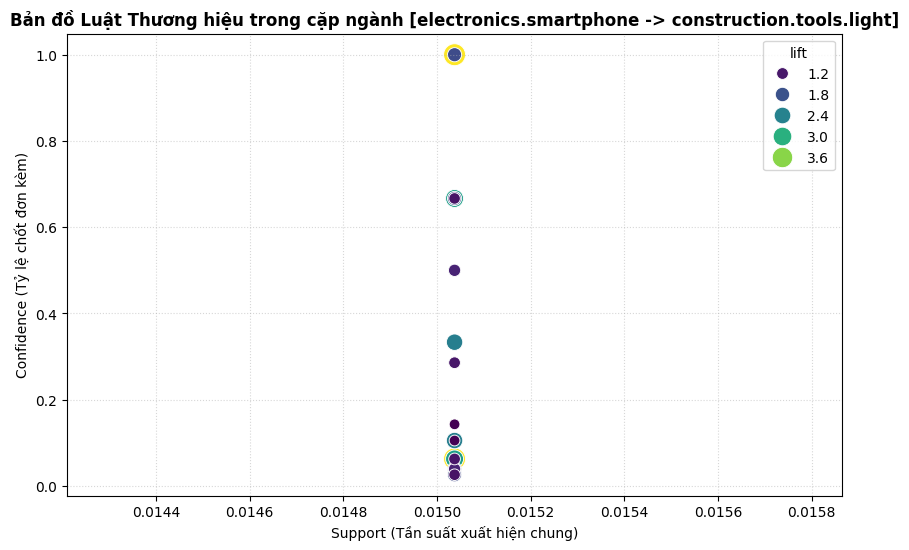

In [ ]:
if len(cat_rules) == 0:
    print("[⚠️] Không tìm thấy luật ngành hàng nào thỏa mãn. Vui lòng hạ min_support ở Phần 1.")
else:
    # Lấy cặp ngành hàng mạnh nhất từ kết quả Giai đoạn 1
    top_rule = cat_rules.iloc[0]
    cat_A = 'electronics.smartphone'
    cat_B = 'construction.tools.light'
    print(f"[💡] Cặp ngành hàng vàng được chọn để mổ xẻ: [{cat_A}] ---> [{cat_B}]")
    print(f"    (Độ tin cậy Confidence: {top_rule['confidence']:.2%}, Hệ số cải tiến Lift: {top_rule['lift']:.2f})")

    # Lọc ra những khách hàng đã từng mua mặt hàng thuộc 1 trong 2 ngành hàng này
    target_users = df_purchases[df_purchases[category_col].isin([cat_A, cat_B])]['user_id'].unique()
    df_filtered = df_purchases[df_purchases['user_id'].isin(target_users)].copy()

    # Gom giỏ hàng mới nhưng lần này thu thập thuộc tính 'brand'
    transactions_brand = df_filtered.groupby('user_id')['brand'].apply(lambda x: list(set(x))).tolist()
    transactions_brand = [t for t in transactions_brand if len(t) > 1]

    print(f"-> Số lượng giỏ hàng cô đọng phục vụ phân tích Brand: {len(transactions_brand)}")

    te_brand = TransactionEncoder()
    te_ary_brand = te_brand.fit(transactions_brand).transform(transactions_brand)
    df_hot_brand = pd.DataFrame(te_ary_brand, columns=te_brand.columns_)

    frequent_brands = apriori(df_hot_brand, min_support=0.015, use_colnames=True)
    brand_rules = association_rules(frequent_brands, metric="lift", min_threshold=1.0)

    # Sắp xếp kết quả luật thương hiệu
    brand_rules = brand_rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

    print(f"\n[★] KẾT QUẢ: Tìm thấy {len(brand_rules)} luật kết hợp thương hiệu chất lượng cao:")
    print(brand_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

    # --- TRỰC QUAN HÓA KẾT QUẢ PHÂN CẤP ---
    if len(brand_rules) > 0:
      plt.figure(figsize=(10, 6))
      sns.scatterplot(
        x='support',
        y='confidence',
        hue='lift',
        size='lift',
        sizes=(60, 250),
        palette='viridis',
        data=brand_rules
      )
      plt.title(f'Bản đồ Luật Thương hiệu trong cặp ngành [{cat_A} -> {cat_B}]', fontsize=12, fontweight='bold')
      plt.xlabel('Support (Tần suất xuất hiện chung)', fontsize=10)
      plt.ylabel('Confidence (Tỷ lệ chốt đơn kèm)', fontsize=10)
      plt.grid(True, linestyle=':', alpha=0.5)
      plt.show()
    else:
      print("[⚠️] Không có luật nào để vẽ biểu đồ.")

**Kết luận:**
1. Các Cặp Thương hiệu (Business Insights).
- Nhóm 1: Liên minh hệ sinh thái Di động & Âm thanh (xiaomi, nokia, jbl, apple, sony)
  - Luật số 0 & 1 (nokia <-> xiaomi | Lift = 4.16): Hệ số Lift lên tới 4.16 (cao nhất bảng). Điều này chứng tỏ khách hàng mua điện thoại Nokia và Xiaomi có mối liên hệ cực kỳ khăng khít. Đây là chân dung của nhóm khách hàng thực tế, ưu tiên các dòng sản phẩm có hiệu năng trên giá thành (Value-for-money).
  - Luật số 2 & 3 (jbl <-> xiaomi | Lift = 2.77): Người mua đồ JBL có xác suất mua kèm đồ Xiaomi rất cao (Confidence = 66.67%). Khách hàng sắm loa/tai nghe JBL thường chọn phối hợp với hệ sinh thái thông minh hoặc smartphone của Xiaomi.
  - Luật số 6 & 7 (sony <-> apple | Lift = 1.74): Đây là phân khúc khách hàng cao cấp/yêu công nghệ. Cứ 10 người mua sản phẩm Sony thì có gần 7 người (Confidence = 66.67%) chốt đơn cùng với Apple. Họ sẵn sàng chi tiền cho các sản phẩm giải trí/công nghệ chất lượng cao.
- Nhóm 2: Sự xuất hiện của thương hiệu chéo ngành (jaguar <-> samsung)
  - Luật số 8 & 9 (jaguar -> samsung | Lift = 1.73): Đây là một phát hiện cực kỳ thú vị từ thuật toán! Jaguar (thường là các thiết bị cơ khí, dụng cụ cầm tay hoặc phụ tùng cao cấp) kết hợp hoàn hảo với Samsung. Đặc biệt, luật jaguar -> samsung có Confidence = 1.00 (100%) — tức là toàn bộ nhóm khách hàng chọn mua thiết bị thầu/dụng cụ của Jaguar trong tệp này đều chọn mua smartphone hoặc thiết bị của Samsung đi kèm.

2. Đề xuất Giải pháp Marketing.
- Chiến lược Cross-selling (Bán kèm) nhóm Phổ thông: Thiết kế gói combo "Giải trí tiết kiệm" kết hợp giữa Xiaomi và JBL. Trên giao diện màn hình thanh toán của sản phẩm loa/tai nghe JBL, hệ thống nên tự động gợi ý phụ kiện hoặc smartphone Xiaomi để tận dụng mức độ tin cậy $66.67\%$.
- Chiến lược Target khách hàng VIP (Apple & Sony): Nhóm khách hàng mua Sony và Apple là nhóm có biên lợi nhuận cao. Hãy tạo chiến dịch khuyến mãi chéo độc quyền: "Mua tai nghe/máy ảnh Sony, tặng voucher giảm giá 5% cho phụ kiện Apple chính hãng".
- Chiến lược B2B/Hộ gia đình (Samsung & Jaguar): Vì mối tương quan giữa dụng cụ thiết bị Jaguar và điện tử Samsung là tuyệt đối ($100\%$),  nên liên hệ với các nhà phân phối để tạo gói thầu combo: "Sắm thiết bị công trình Jaguar - Tặng gói ưu đãi mua thiết bị giám sát/smartphone Samsung cho đội kỹ thuật".